# Распределение следующего токена

Взял датасет на 2к небольших текстов. Взял n первых слов из текста (именно от начала), как пример взял по 3 слова. Закинул в qwen3-4b-base. Потом просто сложил все логиты для каждого текста (не вычитал максимальный на каждом этапе, переполнения нет, потому что датасет маленький). Поделил все логиты на длину датасета (2224 текста) - такая вот температура (без нее у максимального логита вероятность 1).

In [1]:
import torch
import json
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import Dict, List, Any

MODEL_NAME = "Qwen/Qwen3-4B-Base"
TOP_K = 3

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True
)
model.eval()

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2560)
    (layers): ModuleList(
      (0-35): 36 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2560, out_features=4096, bias=False)
          (k_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=2560, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (up_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (down_proj): Linear(in_features=9728, out_features=2560, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2560,), eps=1e-06)
        (post_attention_layer

In [2]:
from datasets import load_dataset

ds = load_dataset("gopalkalpande/bbc-news-summary")
ds = [i["Articles"] for i in ds["train"]]

README.md: 0.00B [00:00, ?B/s]

bbc-news-summary.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/2224 [00:00<?, ? examples/s]

In [3]:
print(ds[0])
print(len(ds))

Budget to set scene for election..Gordon Brown will seek to put the economy at the centre of Labour's bid for a third term in power when he delivers his ninth Budget at 1230 GMT. He is expected to stress the importance of continued economic stability, with low unemployment and interest rates. The chancellor is expected to freeze petrol duty and raise the stamp duty threshold from £60,000. But the Conservatives and Lib Dems insist voters face higher taxes and more means-testing under Labour...Treasury officials have said there will not be a pre-election giveaway, but Mr Brown is thought to have about £2bn to spare...- Increase in the stamp duty threshold from £60,000. - A freeze on petrol duty. - An extension of tax credit scheme for poorer families. - Possible help for pensioners The stamp duty threshold rise is intended to help first time buyers - a likely theme of all three of the main parties' general election manifestos. Ten years ago, buyers had a much greater chance of avoiding s

In [4]:
DATASET_LEN = 2224

In [5]:
def first_n_word_split(dataset: list[str], n: int=1):
    ds = [" ".join(i.split()[:n]) for i in dataset]
    return ds

n3 = first_n_word_split(ds, 3)
n3[0]

'Budget to set'

In [6]:
def get_prob(
    model,
    tokenizer,
    input_ids: torch.Tensor,
    top_k: int = 3,
) -> Dict[str, Any]:
    
    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits[:, -1, :]

    return logits
    

In [7]:
from tqdm.auto import tqdm

total_logits = torch.zeros(([1, 151936])).to(model.device)

for ngram in tqdm(n3, desc="Processing n-grams"):
    inputs = tokenizer(ngram, return_tensors="pt")
    input_ids = inputs.input_ids.to(model.device)
    
    logits = get_prob(model, tokenizer, input_ids, TOP_K)
    total_logits += logits
    # total_logits -= total_logits.max()

total_logits

Processing n-grams:   0%|          | 0/2224 [00:00<?, ?it/s]

tensor([[31802.4238, 30645.1406, 23284.3262,  ..., -1544.1682, -1544.1672,
         -1543.9991]], device='cuda:0')

In [8]:
print(total_logits.min())
print(total_logits.max())
print(total_logits.mean())
print(total_logits.std())

tensor(-12091.8652, device='cuda:0')
tensor(44878.1953, device='cuda:0')
tensor(13085.2969, device='cuda:0')
tensor(6648.7236, device='cuda:0')


In [10]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

print(torch.topk(total_logits, k=50))
print(torch.topk(F.softmax(total_logits/DATASET_LEN, dim=-1), k=50))


torch.return_types.topk(
values=tensor([[44878.1953, 43356.1094, 43190.6953, 43111.8398, 42073.3867, 42027.6875,
         41678.4609, 41482.5156, 41466.7617, 41150.3633, 41012.9258, 40287.3984,
         40212.6562, 39714.9219, 39713.7656, 39306.3594, 39113.4219, 38849.5195,
         38722.8984, 38667.4922, 38662.9102, 38523.7031, 38487.3516, 38432.3906,
         38424.3984, 38335.2031, 38314.7578, 38162.0391, 37991.3516, 37891.5156,
         37842.7539, 37672.1328, 37590.3828, 37588.6133, 37501.7891, 37494.7969,
         37491.5586, 37433.1641, 37414.1250, 37340.4102, 37326.3711, 37300.4531,
         37223.9062, 37202.7305, 37201.8828, 37181.3516, 37063.3984, 36981.8555,
         36958.1328, 36955.0625]], device='cuda:0'),
indices=tensor([[ 220,  279,  304,  264,  311,  364,  323,  389,  198,  369,   11,  518,
          271,  330,  438,  916,  320,   25, 1156,  448,  501, 4102,  458, 3369,
          678,  481,  315,  362,  825,  803,  553,  356,  425,  547, 1182,  705,
          700, 1

Text(0, 0.5, 'Вероятность')

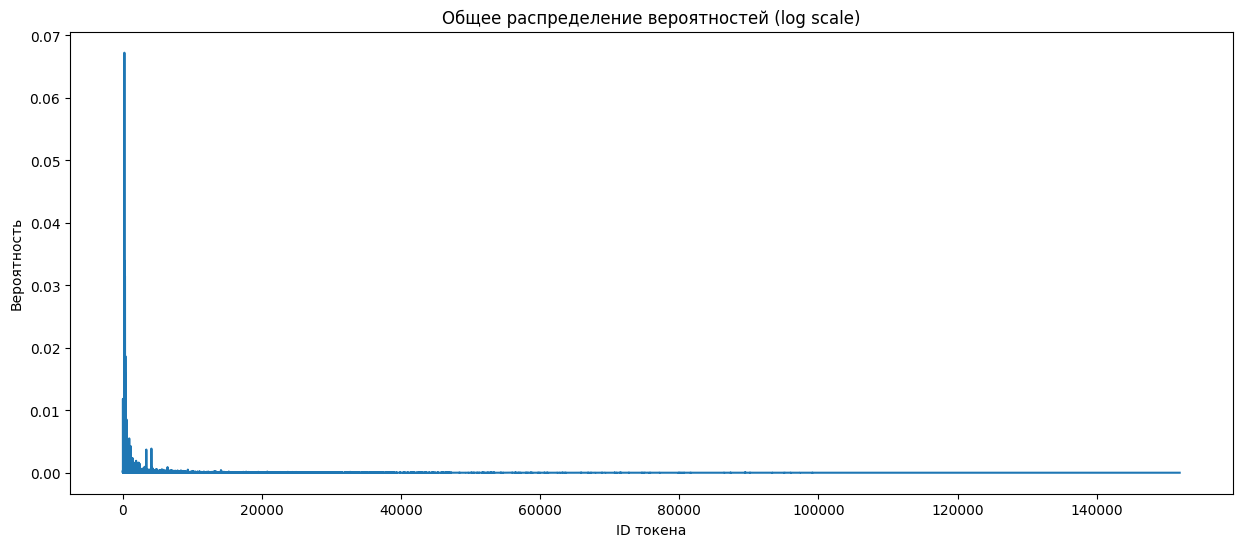

In [11]:
probs = F.softmax(total_logits/DATASET_LEN, dim=-1).cpu().detach().numpy().flatten()

top_k_values, top_k_indices = torch.topk(F.softmax(total_logits/DATASET_LEN, dim=-1), k=50)
top_k_values = top_k_values.cpu().detach().numpy().flatten()
top_k_tokens = [repr(tokenizer.decode([idx])) for idx in top_k_indices[0]]

plt.figure(figsize=(15, 6))

plt.plot(probs)
plt.title("Общее распределение вероятностей (log scale)")
plt.xlabel("ID токена")
plt.ylabel("Вероятность")


Text(0, 0.5, 'Вероятность')

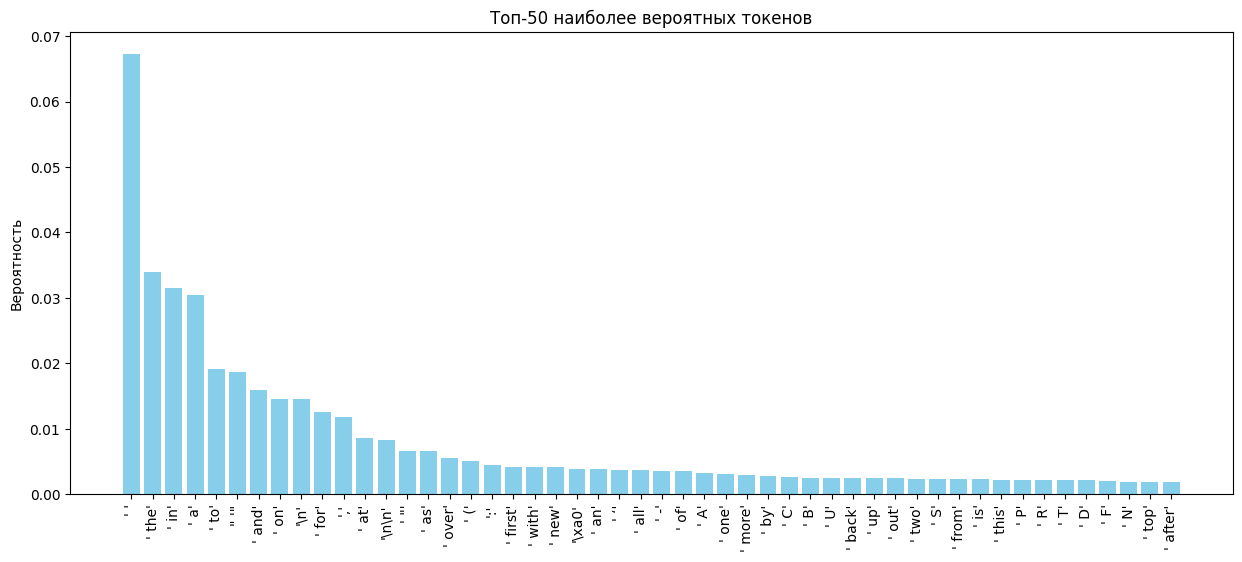

In [12]:
plt.figure(figsize=(15, 6))
plt.bar(range(len(top_k_values)), top_k_values, color='skyblue')
plt.xticks(range(len(top_k_values)), top_k_tokens, rotation=90)
plt.title("Топ-50 наиболее вероятных токенов")
plt.ylabel("Вероятность")